<a href="https://colab.research.google.com/github/Samarth2109/ITA-Project-1/blob/main/Samarth_Singh_Raghuwanshi_IPM06058_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ===============================
# PART 1: Import Required Libraries
# ===============================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
# ===============================
# PART 1: Upload Dataset
# ===============================

from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving January2015toJuly2025.csv to January2015toJuly2025.csv


In [5]:
df = pd.read_csv(
    "January2015toJuly2025.csv",
    engine="python", # Use the Python parsing engine for better flexibility
    on_bad_lines="skip",
    encoding="latin1"
)




# ===============================
# PART 3: Dataset Inspection
# ===============================

print("Dataset Shape:", df.shape)

df.info()

df.isnull().sum()

Dataset Shape: (102922, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102922 entries, 0 to 102921
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      102922 non-null  int64  
 1   UPA                     102922 non-null  int64  
 2   EventDate               102922 non-null  object 
 3   Employer                102922 non-null  object 
 4   Address1                102904 non-null  object 
 5   Address2                9087 non-null    object 
 6   City                    102905 non-null  object 
 7   State                   102922 non-null  object 
 8   Zip                     102898 non-null  float64
 9   Latitude                102855 non-null  float64
 10  Longitude               102855 non-null  float64
 11  Primary NAICS           102920 non-null  object 
 12  Hospitalized            102922 non-null  float64
 13  Amputation              102915 non-null  float

,0
ID,0
UPA,0
EventDate,0
Employer,0
Address1,18
Address2,93835
City,17
State,0
Zip,24
Latitude,67


In [6]:
# ===============================
# PART 4: Select Relevant Features
# ===============================

df = df[['Primary NAICS',
         'Hospitalized',
         'Amputation',
         'Loss of Eye',
         'NatureTitle',
         'Part of Body Title',
         'EventTitle',
         'SourceTitle']]

df.head()

,Primary NAICS,Hospitalized,Amputation,Loss of Eye,NatureTitle,Part of Body Title,EventTitle,SourceTitle
0,922140,1.0,0.0,0.0,Fractures,Lower leg(s),Injured by physical contact with person while ...,Co-worker
1,339999,1.0,0.0,0.0,Second degree heat (thermal) burns,"Leg(s), n.e.c.","Ignition of vapors, gases, or liquids","Welding, cutting, and blow torches"
2,484121,1.0,0.0,0.0,"Traumatic injuries and disorders, unspecified",Nonclassifiable,Other fall to lower level less than 6 feet,"Semi, tractor-trailer, tanker truck"
3,424490,1.0,0.0,0.0,"Soreness, pain, hurt-nonspecified injury","Leg(s), unspecified",Caught in or compressed by equipment or object...,Pallet jack-powered
4,326122,1.0,0.0,0.0,Fractures,"Finger(s), fingernail(s), n.e.c.",Caught in running equipment or machinery durin...,"Metal, woodworking, and special material machi..."


In [7]:
# ===============================
# PART 5: Create Hazard Category
# ===============================

def classify_hazard(row):

    if row['Loss of Eye'] == 1:
        return "Critical Violation"

    elif row['Amputation'] == 1:
        return "High Hazard"

    elif row['Hospitalized'] == 1:
        return "Moderate Risk"

    else:
        return "Safe"

df["HazardLevel"] = df.apply(classify_hazard, axis=1)

df.head()

,Primary NAICS,Hospitalized,Amputation,Loss of Eye,NatureTitle,Part of Body Title,EventTitle,SourceTitle,HazardLevel
0,922140,1.0,0.0,0.0,Fractures,Lower leg(s),Injured by physical contact with person while ...,Co-worker,Moderate Risk
1,339999,1.0,0.0,0.0,Second degree heat (thermal) burns,"Leg(s), n.e.c.","Ignition of vapors, gases, or liquids","Welding, cutting, and blow torches",Moderate Risk
2,484121,1.0,0.0,0.0,"Traumatic injuries and disorders, unspecified",Nonclassifiable,Other fall to lower level less than 6 feet,"Semi, tractor-trailer, tanker truck",Moderate Risk
3,424490,1.0,0.0,0.0,"Soreness, pain, hurt-nonspecified injury","Leg(s), unspecified",Caught in or compressed by equipment or object...,Pallet jack-powered,Moderate Risk
4,326122,1.0,0.0,0.0,Fractures,"Finger(s), fingernail(s), n.e.c.",Caught in running equipment or machinery durin...,"Metal, woodworking, and special material machi...",Moderate Risk


In [8]:
# ===============================
# PART 6: Encode Categorical Variables
# ===============================

label_encoders = {}

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

In [9]:
# ===============================
# PART 7: Define X and y
# ===============================

X = df.drop(["HazardLevel", "Hospitalized", "Amputation", "Loss of Eye"], axis=1)

y = df["HazardLevel"]

In [10]:
# ===============================
# PART 8: Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# ===============================
# PART 9: Train Random Forest Model
# ===============================

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# ===============================
# PART 10: Make Predictions
# ===============================

y_pred = model.predict(X_test)

In [18]:
# ===============================
# PART 11: Model Evaluation
# ===============================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.986737915958222

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
           1       0.98      0.99      0.99      5337
           2       0.99      0.99      0.99     15114
           3       0.17      0.02      0.04       125

    accuracy                           0.99     20585
   macro avg       0.78      0.64      0.68     20585
weighted avg       0.98      0.99      0.98     20585


Confusion Matrix:

[[    5     0     4     0]
 [    0  5288    49     0]
 [    0    83 15016    15]
 [    0     3   119     3]]


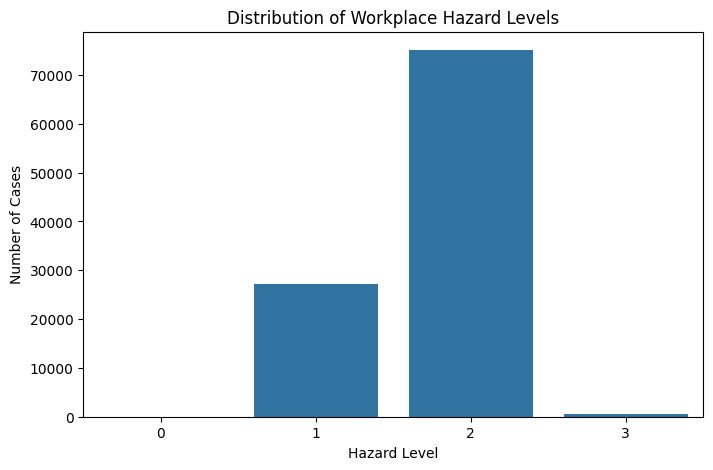

In [14]:
# ===============================
# PART 12: Hazard Distribution
# ===============================

plt.figure(figsize=(8,5))

sns.countplot(x='HazardLevel', data=df)

plt.title("Distribution of Workplace Hazard Levels")
plt.xlabel("Hazard Level")
plt.ylabel("Number of Cases")

plt.show()

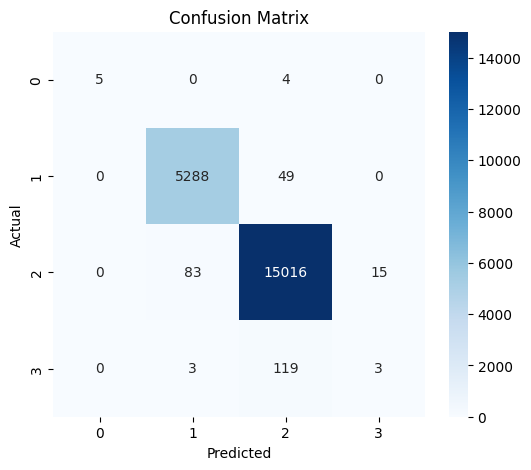

In [15]:
# ===============================
# PART 13: Confusion Matrix Visualization
# ===============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

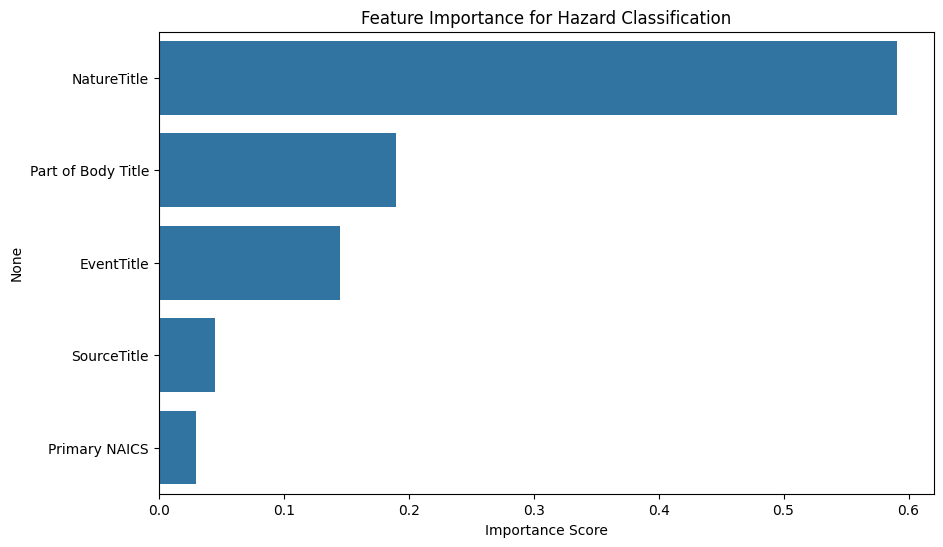

In [16]:
# ===============================
# PART 14: Feature Importance
# ===============================

feature_importances = pd.Series(model.feature_importances_, index=X.columns)

feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x=feature_importances, y=feature_importances.index)

plt.title("Feature Importance for Hazard Classification")
plt.xlabel("Importance Score")

plt.show()

In [17]:
# ===============================
# PART 15: Example Hazard Prediction
# ===============================

sample_workplace = X.iloc[0:1]

prediction = model.predict(sample_workplace)

print("Predicted Hazard Level:", prediction)

Predicted Hazard Level: [2]
